#### Подключение PySpark, загрузка библиотек, настройка изображений

In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, mean, countDistinct, count, size, when, regexp_extract, split

sns.set_style('darkgrid')
params = {'legend.fontsize': 'medium', 'figure.figsize': (10,8), 'figure.dpi': 100, 'axes.labelsize':'medium', 'axes.titlesize':'medium', 'xtick.labelsize': 'medium', 'xtick.labelsize': 'medium'}
plt.rcParams.update(params)

#### Запуск сессии PySpark

In [3]:
spark = SparkSession.builder.appName('EDA Films').getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/22 15:54:43 WARN Utils: Your hostname, Artems-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.149 instead (on interface en0)
26/04/22 15:54:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/22 15:54:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


#### Загрузка и обзор датасетов

In [4]:
df_movies = spark.read.csv('sp_movies.csv', header=True, inferSchema=True)
df_ratings = spark.read.csv('sp_ratings.csv', header=True, inferSchema=True)
df_tags = spark.read.csv('sp_tags.csv', header=True, inferSchema=True)

In [5]:
df_movies.show(5)

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows


In [6]:
df_ratings.show(5)

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|      1|   4.0|964982703|
|     1|      3|   4.0|964981247|
|     1|      6|   4.0|964982224|
|     1|     47|   5.0|964983815|
|     1|     50|   5.0|964982931|
+------+-------+------+---------+
only showing top 5 rows


In [7]:
df_tags.show(5)

+------+-------+---------------+----------+
|userId|movieId|            tag| timestamp|
+------+-------+---------------+----------+
|     2|  60756|          funny|1445714994|
|     2|  60756|Highly quotable|1445714996|
|     2|  60756|   will ferrell|1445714992|
|     2|  89774|   Boxing story|1445715207|
|     2|  89774|            MMA|1445715200|
+------+-------+---------------+----------+
only showing top 5 rows


#### Статистика данных

In [8]:
print('Количество пользователей поставивших оценку:')
df_ratings.select(countDistinct('userId')).show()

Количество пользователей поставивших оценку:
+----------------------+
|count(DISTINCT userId)|
+----------------------+
|                   610|
+----------------------+



In [9]:
print('Количество оцененных фильмов:')
df_ratings.select(countDistinct('movieId')).show()

Количество оцененных фильмов:
+-----------------------+
|count(DISTINCT movieId)|
+-----------------------+
|                   9724|
+-----------------------+



In [10]:
print('Количество фильмов с отметками комментариев:')
df_tags.select(countDistinct('movieId')).show()

Количество фильмов с отметками комментариев:
+-----------------------+
|count(DISTINCT movieId)|
+-----------------------+
|                   1572|
+-----------------------+



#### Предобработка и настройка данных

In [11]:
df1 = df_ratings.alias('df1')
df2 = df_tags.alias('df2')
df3 = df_movies.alias('df3')

In [13]:
df3.show(5)

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows


#### Извлечения года из названия

In [14]:
df3 = df3.withColumn('year', regexp_extract(df3['title'], r'\((\d{4})\)', 1))

In [15]:
df3.show(5)

+-------+--------------------+--------------------+----+
|movieId|               title|              genres|year|
+-------+--------------------+--------------------+----+
|      1|    Toy Story (1995)|Adventure|Animati...|1995|
|      2|      Jumanji (1995)|Adventure|Childre...|1995|
|      3|Grumpier Old Men ...|      Comedy|Romance|1995|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|1995|
|      5|Father of the Bri...|              Comedy|1995|
+-------+--------------------+--------------------+----+
only showing top 5 rows


In [16]:
df_movies.show(5)

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows


#### Извлечение информации о жанрах

In [21]:
from pyspark.sql.functions import split, col, when, sum as spark_sum, get

split_expr = split(df3['genres'], '\\|')

for i in range(1, 11):
    df3 = df3.withColumn(f'genre{i}', get(split_expr, i - 1))

genre_columns = [f'genre{i}' for i in range(1, 11)]

for col_name in genre_columns:
    df3 = df3.withColumn(col_name, col(col_name).cast('string'))

genre_count_expr = sum(
    when(col(col_name).isNotNull() & (col(col_name) != '0'), 1).otherwise(0)
    for col_name in genre_columns
)

df3 = df3.withColumn('genre_count', genre_count_expr)

In [22]:
df3.show()

+-------+--------------------+--------------------+----+---------+---------+--------+------+--------+------+------+------+------+-------+-----------+
|movieId|               title|              genres|year|   genre1|   genre2|  genre3|genre4|  genre5|genre6|genre7|genre8|genre9|genre10|genre_count|
+-------+--------------------+--------------------+----+---------+---------+--------+------+--------+------+------+------+------+-------+-----------+
|      1|    Toy Story (1995)|Adventure|Animati...|1995|Adventure|Animation|Children|Comedy| Fantasy|  NULL|  NULL|  NULL|  NULL|   NULL|          5|
|      2|      Jumanji (1995)|Adventure|Childre...|1995|Adventure| Children| Fantasy|  NULL|    NULL|  NULL|  NULL|  NULL|  NULL|   NULL|          3|
|      3|Grumpier Old Men ...|      Comedy|Romance|1995|   Comedy|  Romance|    NULL|  NULL|    NULL|  NULL|  NULL|  NULL|  NULL|   NULL|          2|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|1995|   Comedy|    Drama| Romance|  NULL|    NULL

#### Анализ данных

In [23]:
df1.show()

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|      1|   4.0|964982703|
|     1|      3|   4.0|964981247|
|     1|      6|   4.0|964982224|
|     1|     47|   5.0|964983815|
|     1|     50|   5.0|964982931|
|     1|     70|   3.0|964982400|
|     1|    101|   5.0|964980868|
|     1|    110|   4.0|964982176|
|     1|    151|   5.0|964984041|
|     1|    157|   5.0|964984100|
|     1|    163|   5.0|964983650|
|     1|    216|   5.0|964981208|
|     1|    223|   3.0|964980985|
|     1|    231|   5.0|964981179|
|     1|    235|   4.0|964980908|
|     1|    260|   5.0|964981680|
|     1|    296|   3.0|964982967|
|     1|    316|   3.0|964982310|
|     1|    333|   5.0|964981179|
|     1|    349|   4.0|964982563|
+------+-------+------+---------+
only showing top 20 rows


In [24]:
rating_avg = df1.groupBy('movieId').agg(mean('rating')).alias('rating_avg')
rating_avg = rating_avg.withColumnRenamed('movieId', 'movieId_avg')
rating_avg.show(5)

+-----------+-----------------+
|movieId_avg|      avg(rating)|
+-----------+-----------------+
|       1580|3.487878787878788|
|       2366|             3.64|
|       3175|             3.58|
|       1088|3.369047619047619|
|      32460|             4.25|
+-----------+-----------------+
only showing top 5 rows


In [25]:
rating_count = df1.groupBy('movieId').agg(count('rating')).alias('rating_count')
rating_count = rating_count.withColumnRenamed('movieId', 'movieId_count')
rating_count.show(5)

+-------------+-------------+
|movieId_count|count(rating)|
+-------------+-------------+
|         1580|          165|
|         2366|           25|
|         3175|           75|
|         1088|           42|
|        32460|            4|
+-------------+-------------+
only showing top 5 rows


In [26]:
user_rating = df1.groupBy('userId').agg(mean('rating')).alias('user_rating_avg')
user_rating = user_rating.withColumnRenamed('userId', 'userId_avg')
user_rating.show(5)

+----------+------------------+
|userId_avg|       avg(rating)|
+----------+------------------+
|       148|3.7395833333333335|
|       463| 3.787878787878788|
|       471|             3.875|
|       496| 3.413793103448276|
|       243| 4.138888888888889|
+----------+------------------+
only showing top 5 rows


In [27]:
user_count = df1.groupBy('userId').agg(count('rating')).alias('user_rating_count')
user_count = user_count.withColumnRenamed('userId', 'userId_count')
user_count.show(5)

+------------+-------------+
|userId_count|count(rating)|
+------------+-------------+
|         148|           48|
|         463|           33|
|         471|           28|
|         496|           29|
|         243|           36|
+------------+-------------+
only showing top 5 rows


In [28]:
df_user = user_rating.join(user_count, col('userId_avg') == col('userId_count'), 'inner').drop('userId_count')
df_user.show(5)

+----------+------------------+-------------+
|userId_avg|       avg(rating)|count(rating)|
+----------+------------------+-------------+
|       148|3.7395833333333335|           48|
|       463| 3.787878787878788|           33|
|       471|             3.875|           28|
|       496| 3.413793103448276|           29|
|       243| 4.138888888888889|           36|
+----------+------------------+-------------+
only showing top 5 rows


In [29]:
df_user.sort(col('count(rating)').desc()).show()

+----------+------------------+-------------+
|userId_avg|       avg(rating)|count(rating)|
+----------+------------------+-------------+
|       414| 3.391957005189029|         2698|
|       599|2.6420500403551253|         2478|
|       474| 3.398956356736243|         2108|
|       448|2.8473712446351933|         1864|
|       274| 3.235884101040119|         1346|
|       610|3.6885560675883258|         1302|
|        68| 3.233730158730159|         1260|
|       380|3.6732348111658455|         1218|
|       606|3.6573991031390136|         1115|
|       288|3.1459715639810426|         1055|
|       249|3.6964627151051626|         1046|
|       387|3.2585199610516065|         1027|
|       182|3.5112589559877176|          977|
|       307|2.6656410256410257|          975|
|       603|3.5079533404029695|          943|
|       298| 2.363684771033014|          939|
|       177| 3.375553097345133|          904|
|       318| 3.755972696245734|          879|
|       232|3.2505800464037122|   

In [32]:
df_movie = rating_avg.join(rating_count, col('movieId_avg') == col('movieId_count'), 'inner').drop('movieId_count')
df_movie.show(5)

+-----------+-----------------+-------------+
|movieId_avg|      avg(rating)|count(rating)|
+-----------+-----------------+-------------+
|       1580|3.487878787878788|          165|
|       2366|             3.64|           25|
|       3175|             3.58|           75|
|       1088|3.369047619047619|           42|
|      32460|             4.25|            4|
+-----------+-----------------+-------------+
only showing top 5 rows


In [30]:
df_user.sort(col('avg(rating)').desc()).show()

+----------+------------------+-------------+
|userId_avg|       avg(rating)|count(rating)|
+----------+------------------+-------------+
|        53|               5.0|           20|
|       251| 4.869565217391305|           23|
|       515| 4.846153846153846|           26|
|        25|4.8076923076923075|           26|
|        30| 4.735294117647059|           34|
|       523| 4.693333333333333|           75|
|       348| 4.672727272727273|           55|
|       171| 4.634146341463414|           82|
|       452| 4.556930693069307|          202|
|        43| 4.552631578947368|          114|
|       371| 4.548780487804878|           41|
|       122| 4.546232876712328|          292|
|       441| 4.522222222222222|           45|
|       400| 4.511627906976744|           43|
|        52| 4.476923076923077|          130|
|       538| 4.472972972972973|           37|
|       168| 4.462765957446808|           94|
|       417| 4.462686567164179|           67|
|       543| 4.453947368421052|   

In [33]:
df_movie.sort(col('avg(rating)').desc()).show()

+-----------+-----------+-------------+
|movieId_avg|avg(rating)|count(rating)|
+-----------+-----------+-------------+
|      26350|        5.0|            1|
|       3795|        5.0|            1|
|      25887|        5.0|            1|
|     157775|        5.0|            1|
|        633|        5.0|            1|
|      33138|        5.0|            1|
|      67618|        5.0|            1|
|        876|        5.0|            1|
|        496|        5.0|            1|
|      27373|        5.0|            1|
|     113829|        5.0|            1|
|      53578|        5.0|            1|
|     152711|        5.0|            1|
|     118894|        5.0|            1|
|         53|        5.0|            2|
|     160644|        5.0|            1|
|        148|        5.0|            1|
|      84273|        5.0|            1|
|     159811|        5.0|            1|
|     150554|        5.0|            1|
+-----------+-----------+-------------+
only showing top 20 rows


In [34]:
df_user = user_rating.join(user_count, col('userId_avg') == col('userId_count'), 'inner').drop('userId_count')
df_user.show(5)

+----------+------------------+-------------+
|userId_avg|       avg(rating)|count(rating)|
+----------+------------------+-------------+
|       148|3.7395833333333335|           48|
|       463| 3.787878787878788|           33|
|       471|             3.875|           28|
|       496| 3.413793103448276|           29|
|       243| 4.138888888888889|           36|
+----------+------------------+-------------+
only showing top 5 rows


In [35]:
df_user.sort(col('count(rating)').desc()).show(5)

+----------+------------------+-------------+
|userId_avg|       avg(rating)|count(rating)|
+----------+------------------+-------------+
|       414| 3.391957005189029|         2698|
|       599|2.6420500403551253|         2478|
|       474| 3.398956356736243|         2108|
|       448|2.8473712446351933|         1864|
|       274| 3.235884101040119|         1346|
+----------+------------------+-------------+
only showing top 5 rows


In [37]:
df_movie.sort(col('avg(rating)').desc()).show()

+-----------+-----------+-------------+
|movieId_avg|avg(rating)|count(rating)|
+-----------+-----------+-------------+
|      26350|        5.0|            1|
|       3795|        5.0|            1|
|      25887|        5.0|            1|
|     157775|        5.0|            1|
|        633|        5.0|            1|
|      33138|        5.0|            1|
|      67618|        5.0|            1|
|        876|        5.0|            1|
|        496|        5.0|            1|
|      27373|        5.0|            1|
|     113829|        5.0|            1|
|      53578|        5.0|            1|
|     152711|        5.0|            1|
|     118894|        5.0|            1|
|         53|        5.0|            2|
|     160644|        5.0|            1|
|        148|        5.0|            1|
|      84273|        5.0|            1|
|     159811|        5.0|            1|
|     150554|        5.0|            1|
+-----------+-----------+-------------+
only showing top 20 rows


In [38]:
df_movie = df_movie.withColumnRenamed('movieId_avg', 'movieId')

In [39]:
dfk = df3.select('movieId', df3['genre1'])
df2 = df2.join(dfk, on='movieId', how='inner')

In [41]:
df2.show()

+-------+------+----------------+----------+---------+
|movieId|userId|             tag| timestamp|   genre1|
+-------+------+----------------+----------+---------+
|      1|   567|             fun|1525286013|Adventure|
|      1|   474|           pixar|1137206825|Adventure|
|      1|   336|           pixar|1139045764|Adventure|
|      2|   474|            game|1137375552|Adventure|
|      2|    62|  Robin Williams|1528843907|Adventure|
|      2|    62|magic board game|1528843932|Adventure|
|      2|    62|         fantasy|1528843929|Adventure|
|      3|   289|             old|1143424860|   Comedy|
|      3|   289|           moldy|1143424860|   Comedy|
|      5|   474|          remake|1137373903|   Comedy|
|      5|   474|       pregnancy|1137373903|   Comedy|
|      7|   474|          remake|1137375642|   Comedy|
|     11|   474|       president|1137374904|   Comedy|
|     11|   474|        politics|1137374904|   Comedy|
|     14|   474|       president|1137375623|    Drama|
|     14| 

In [42]:
df_movie_renamed = df_movie.withColumnRenamed('movieId_avg', 'movieId')

In [43]:
df3 = df3.join(df_movie_renamed, on='movieId', how='inner')

In [44]:
df3.show(5)

+-------+--------------------+--------------------+----+---------+---------+-------+------+------+------+------+------+------+-------+-----------+-----------------+-------------+
|movieId|               title|              genres|year|   genre1|   genre2| genre3|genre4|genre5|genre6|genre7|genre8|genre9|genre10|genre_count|      avg(rating)|count(rating)|
+-------+--------------------+--------------------+----+---------+---------+-------+------+------+------+------+------+------+-------+-----------+-----------------+-------------+
|   1580|Men in Black (a.k...|Action|Comedy|Sci-Fi|1997|   Action|   Comedy| Sci-Fi|  NULL|  NULL|  NULL|  NULL|  NULL|  NULL|   NULL|          3|3.487878787878788|          165|
|   2366|    King Kong (1933)|Action|Adventure|...|1933|   Action|Adventure|Fantasy|Horror|  NULL|  NULL|  NULL|  NULL|  NULL|   NULL|          4|             3.64|           25|
|   3175| Galaxy Quest (1999)|Adventure|Comedy|...|1999|Adventure|   Comedy| Sci-Fi|  NULL|  NULL|  NULL|

In [45]:
df3 = df3.withColumnRenamed('avg(rating)', 'rating')
df3 = df3.withColumnRenamed('count(rating)', 'rating_count')

In [46]:
df3.show(5)

+-------+--------------------+--------------------+----+---------+---------+-------+------+------+------+------+------+------+-------+-----------+-----------------+------------+
|movieId|               title|              genres|year|   genre1|   genre2| genre3|genre4|genre5|genre6|genre7|genre8|genre9|genre10|genre_count|           rating|rating_count|
+-------+--------------------+--------------------+----+---------+---------+-------+------+------+------+------+------+------+-------+-----------+-----------------+------------+
|   1580|Men in Black (a.k...|Action|Comedy|Sci-Fi|1997|   Action|   Comedy| Sci-Fi|  NULL|  NULL|  NULL|  NULL|  NULL|  NULL|   NULL|          3|3.487878787878788|         165|
|   2366|    King Kong (1933)|Action|Adventure|...|1933|   Action|Adventure|Fantasy|Horror|  NULL|  NULL|  NULL|  NULL|  NULL|   NULL|          4|             3.64|          25|
|   3175| Galaxy Quest (1999)|Adventure|Comedy|...|1999|Adventure|   Comedy| Sci-Fi|  NULL|  NULL|  NULL|  NUL

#### Лучшие фильмы по жанрам

In [49]:
df3.groupBy('genre1').agg({'rating': 'avg', 'rating_count':'sum'}).withColumnRenamed('avg(rating)', 'avg_rating').withColumnRenamed('sum(rating_count)', 'total_vote').orderBy(col('avg_rating').desc()).show()

+------------------+------------------+----------+
|            genre1|        avg_rating|total_vote|
+------------------+------------------+----------+
|         Film-Noir|3.8562184343434347|       112|
|       Documentary|3.7889134809499603|      1015|
|         Animation| 3.574865409400964|      2549|
|               War|             3.525|         9|
|           Western|3.4715869878913357|       151|
|             Drama|3.4609149865486173|     17068|
|             Crime|3.4122601226160905|      6610|
|(no genres listed)|3.3711484593837535|        47|
|         Adventure|3.2851788575659153|     10344|
|           Musical| 3.276388888888889|       134|
|           Romance|3.2052944862155393|       125|
|            Comedy| 3.193690704718599|     25217|
|           Fantasy|3.1797741128192873|       315|
|           Mystery|3.1481526997179983|       976|
|            Action|3.0944984491955116|     30635|
|            Sci-Fi|3.0669590956205637|       343|
|          Thriller| 3.00717008

#### Фильмы с высоким рейтингом (при условии min голосов)

In [52]:
df3.filter(col('rating_count') > 30).orderBy(col('rating').desc()).select('title', 'year', 'rating', 'rating_count').show(10, truncate=False)

+---------------------------------------------------------------------------+----+-----------------+------------+
|title                                                                      |year|rating           |rating_count|
+---------------------------------------------------------------------------+----+-----------------+------------+
|Shawshank Redemption, The (1994)                                           |1994|4.429022082018927|317         |
|Lawrence of Arabia (1962)                                                  |1962|4.3              |45          |
|Godfather, The (1972)                                                      |1972|4.2890625        |192         |
|Fight Club (1999)                                                          |1999|4.272935779816514|218         |
|Cool Hand Luke (1967)                                                      |1967|4.271929824561403|57          |
|Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)|1964|4.2680

#### Распределение рейтингов по годам

In [53]:
df3.groupBy('year').avg('rating').withColumnRenamed('avg(rating)', 'avg_rating').orderBy('year').show(20)

+----+------------------+
|year|        avg_rating|
+----+------------------+
|    |3.7115384615384617|
|1902|               3.5|
|1903|               2.5|
|1908|               4.0|
|1915|               2.0|
|1916|            3.5625|
|1917|               4.5|
|1919|               2.0|
|1920| 3.678571428571429|
|1921|               4.1|
|1922|           3.53125|
|1923|            3.5625|
|1924|               3.7|
|1925| 3.680357142857143|
|1926|               4.0|
|1927|3.2653061224489797|
|1928|3.7145833333333336|
|1929|3.5833333333333335|
|1930|             3.995|
|1931| 3.263539891481068|
+----+------------------+
only showing top 20 rows


In [57]:
df3.groupBy('year').avg('rating').withColumnRenamed('avg(rating)', 'avg_rating').orderBy('avg_rating').show(20)

+----+------------------+
|year|        avg_rating|
+----+------------------+
|1915|               2.0|
|1919|               2.0|
|1903|               2.5|
|1991|3.0305636860845455|
|1987|3.0418536020809985|
|1989|3.0458787265644514|
|1988|3.0607815165942096|
|2015| 3.069094481486622|
|1992|  3.09240209046628|
|1994|3.0966962789303225|
|2016|3.1037478772713865|
|1990|3.1089089186206684|
|2014| 3.113463769437626|
|1998|3.1422720766168633|
|1985|3.1540175110911512|
|1993| 3.159376715565034|
|1997|3.1675036233527885|
|1995|3.1766111709403697|
|2012|3.1783623736766464|
|1986| 3.192034955543565|
+----+------------------+
only showing top 20 rows


#### Средний рейтинг по жанрам

In [58]:
genre_avg = df3.groupBy('genre1').agg({'rating': 'avg'}).withColumnRenamed('avg(rating)', 'avg_rating').orderBy('avg_rating', ascending = False)

In [59]:
p_df = genre_avg.toPandas()

/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_24717/2326948398.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=p_df, x = 'avg_rating', y='genre1', palette='viridis')


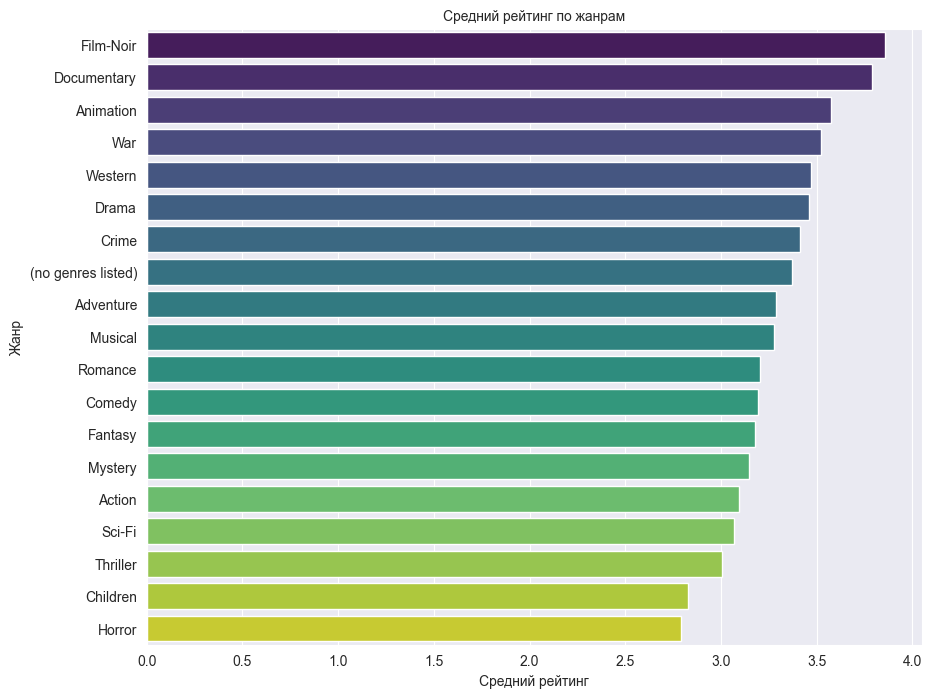

In [60]:
sns.barplot(data=p_df, x = 'avg_rating', y='genre1', palette='viridis')
plt.title('Средний рейтинг по жанрам')
plt.xlabel('Средний рейтинг')
plt.ylabel('Жанр')
plt.show()

#### Диаграмма рассеяния "Рейтинг / Кол-во голосов"

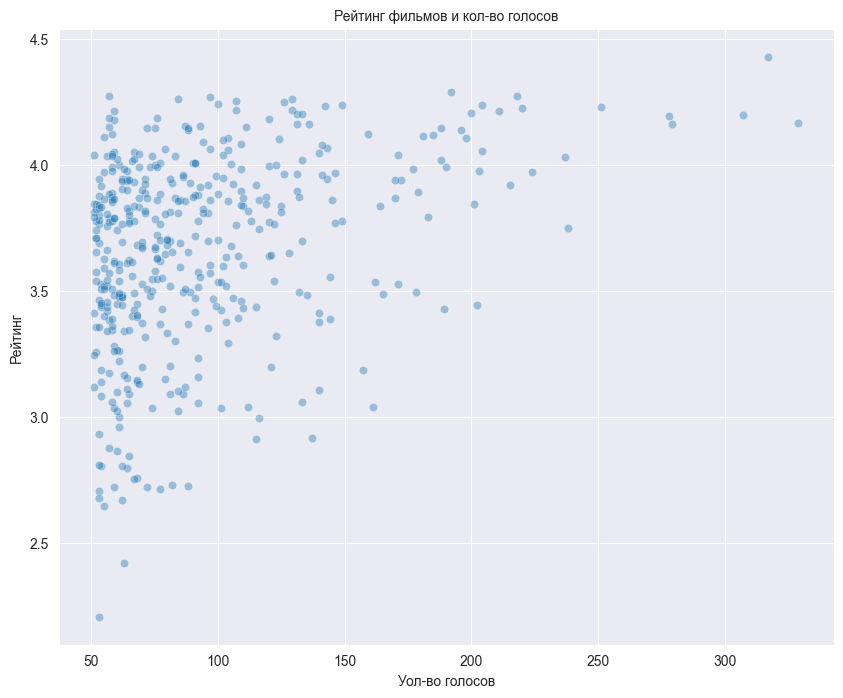

In [65]:
top = df3.filter(df3.rating_count > 50).select('rating', 'rating_count').toPandas()
sns.scatterplot(data=top, x='rating_count', y='rating', alpha = 0.4)
plt.title('Рейтинг фильмов и кол-во голосов')
plt.xlabel('Уол-во голосов')
plt.ylabel('Рейтинг')
#plt.xscale('log')
plt.show()